In [6]:
# Standard imports
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

import os
os.makedirs("models", exist_ok=True)

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)


import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# Project modules
from src.data.preprocess import load_and_clean_data
from src.features.build_features import engineer_features

# Load data, labels, and clusters
data, labels = load_and_clean_data()
data_eng = engineer_features(data)
pipeline = joblib.load(models_dir /"preprocessing_pipeline.pkl")
db_model = joblib.load(models_dir / "champion_dbscan.pkl")

X = pipeline.transform(data_eng)
clusters = db_model.fit_predict(X)

# Combine everything
df_analysis = data_eng.copy()
df_analysis['cluster'] = clusters
df_analysis = pd.concat([df_analysis, labels.reset_index(drop=True)], axis=1)

print("Cluster Distribution:")
print(df_analysis['cluster'].value_counts().sort_index())

# Failure rate per cluster
failure_rate = df_analysis.groupby('cluster')['Machine failure'].mean()
print("\nFailure Rate by Cluster:")
print(failure_rate.round(4))

# Failure mode breakdown per cluster
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for mode in failure_modes:
    print(f"\n{mode} rate by cluster:")
    print(df_analysis.groupby('cluster')[mode].mean().round(4))


INFO:root:Resolved full path: C:\ws-python\predictive-maintenance-clustering\data\raw\ai4i2020.csv


INFO:root:Loaded dataset with shape: (10000, 14)
INFO:root:Features shape: (10000, 6) | Labels shape: (10000, 6)


Cluster Distribution:
cluster
-1     196
 0    9793
 1      11
Name: count, dtype: int64

Failure Rate by Cluster:
cluster
-1    0.2857
 0    0.0289
 1    0.0000
Name: Machine failure, dtype: float64

TWF rate by cluster:
cluster
-1    0.0102
 0    0.0045
 1    0.0000
Name: TWF, dtype: float64

HDF rate by cluster:
cluster
-1    0.0102
 0    0.0115
 1    0.0000
Name: HDF, dtype: float64

PWF rate by cluster:
cluster
-1    0.2398
 0    0.0049
 1    0.0000
Name: PWF, dtype: float64

OSF rate by cluster:
cluster
-1    0.0459
 0    0.0091
 1    0.0000
Name: OSF, dtype: float64

RNF rate by cluster:
cluster
-1    0.0000
 0    0.0019
 1    0.0000
Name: RNF, dtype: float64


DBSCAN found 2 clusters and 196 noise points.
Cluster profile (mean feature values):


,power_proxy,Tool wear [min]
cluster,,
-1,45429.717,106.383
0,60257.998,107.904
1,60061.427,178.182


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


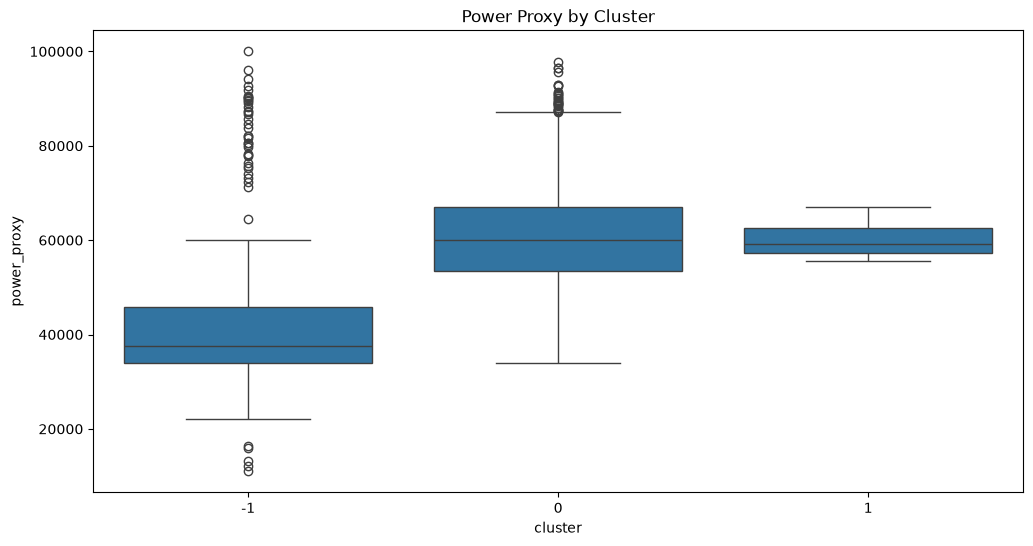

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


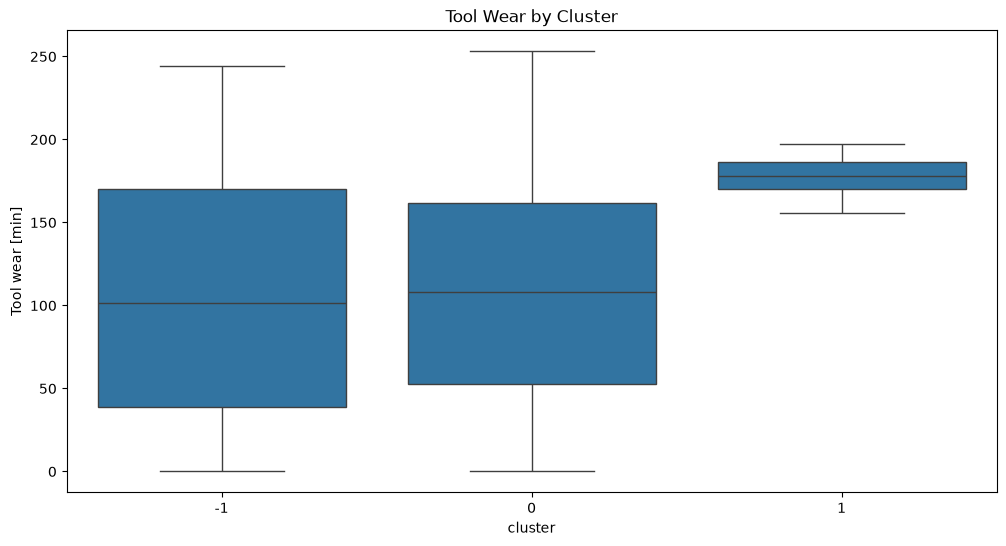

In [10]:
# DBSCAN does not produce centroids. Use cluster profiles instead.
cluster_counts = df_analysis['cluster'].value_counts().sort_index()
noise_count = cluster_counts.get(-1, 0)
n_clusters = len(cluster_counts) - (1 if -1 in cluster_counts.index else 0)
print(f"DBSCAN found {n_clusters} clusters and {noise_count} noise points.")

cluster_profiles = df_analysis.groupby('cluster').mean(numeric_only=True)
print("Cluster profile (mean feature values):")
display(cluster_profiles[['power_proxy', 'Tool wear [min]']].round(3))

# Visualize key features by cluster
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analysis, x='cluster', y='power_proxy')
plt.title("Power Proxy by Cluster")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analysis, x='cluster', y='Tool wear [min]')
plt.title("Tool Wear by Cluster")
plt.show()

## SHAP-like Explainability for K-Means (using centroids or surrogate):


In [12]:
# Simple feature importance via cluster mean deviation
import numpy as np
overall_mean = X.mean(axis=0)
cluster_labels = np.array(clusters)
valid_clusters = sorted([c for c in set(cluster_labels) if c != -1])
if valid_clusters:
    cluster_means = np.vstack([X[cluster_labels == c].mean(axis=0) for c in valid_clusters])
    importance = np.abs(cluster_means - overall_mean).mean(axis=0)
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    if len(feature_names) != len(importance):
        feature_names = [f"feature_{i+1}" for i in range(len(importance))]
    feature_importance = pd.Series(importance, index=feature_names)
    print("Top driving features:")
    print(feature_importance.sort_values(ascending=False).head(8))
else:
    print("Not enough clusters to compute cluster-driven importance.")

Top driving features:
feature_1    1.284665
feature_2    1.248044
feature_3    0.589603
dtype: float64


## Limitations
### Key Limitations of This Unsupervised Approach:

* No direct optimization against a business metric (e.g., failure prediction) during training — relies on post-hoc validation.
* Sensitive to scaling choices, feature engineering, and hyper-parameters (especially DBSCAN eps).
* Clusters may be unstable with new data distributions (concept drift in real factories).
* High-dimensional telemetry can still suffer from curse of dimensionality even after PCA.
* Cannot distinguish rare but critical failures if they don't form dense clusters.
* Requires domain expert interpretation of clusters.

**Mitigation in Production**: Combine with supervised models on labeled data when available, use online clustering for drift detection, and implement human-in-the-loop review.

## Bias & Fairness Audit

**Focus**: Product quality variant (Type: L, M, H) is a sensitive attribute (low-quality machines may be cheaper and more prone to issues).

**Bias Audit Code**

In [13]:
# Cluster distribution by machine Type
type_cluster = pd.crosstab(df_analysis['Type'], df_analysis['cluster'], normalize='index')
print("Proportion of each Type in Clusters:")
display(type_cluster.round(3))

# Failure rate vs cluster vs Type
bias_summary = df_analysis.groupby(['Type', 'cluster'])['Machine failure'].agg(['mean', 'count'])
print("\nFailure Rate by Type & Cluster:")
display(bias_summary)

# Disparate Impact Analysis (example: proportion in "high-risk" cluster)
high_risk_clusters = [cluster for cluster, rate in failure_rate.items() if rate > failure_rate.mean() * 1.5]
print(f"\nHigh-risk clusters: {high_risk_clusters}")

for t in ['L', 'M', 'H']:
    prop_high_risk = (df_analysis[df_analysis['Type'] == t]['cluster']
                     .isin(high_risk_clusters).mean())
    print(f"Type {t} in high-risk clusters: {prop_high_risk:.1%}")

Proportion of each Type in Clusters:


cluster,-1,0,1
Type,,,
H,0.014,0.985,0.001
L,0.019,0.980,0.001
M,0.022,0.976,0.002



Failure Rate by Type & Cluster:


mean  count
Type cluster                 
H    -1       0.142857     14
      0       0.019231    988
      1       0.000000      1
L    -1       0.304348    115
      0       0.034008   5881
      1       0.000000      4
M    -1       0.283582     67
      0       0.021888   2924
      1       0.000000      6


High-risk clusters: [-1]
Type L in high-risk clusters: 1.9%
Type M in high-risk clusters: 2.2%
Type H in high-risk clusters: 1.4%
